In [1]:
import sys
import metpy.calc as mpcalc
import metpy.units as units
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import tqdm
import glob
from dask.distributed import Client
import pandas as pd

sys.path.append('/g/data/ng72/ab4502/hot-cloudy/modules/')
from fronts import *

In [2]:
client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37903 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/37903/status,
Dashboard: /proxy/37903/status,Workers: 7
Total threads: 7,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33321,Workers: 0
Dashboard: /proxy/37903/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36599,Total threads: 1
Dashboard: /proxy/33129/status,Memory: 4.57 GiB
Nanny: tcp://127.0.0.1:40505,


2026-02-10 17:02:37,731 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('groupby-cohort-2d1778c5942028a3324244c9b98c12ec', 0, 0, 0) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: <Task ('groupby-cohort-2d1778c5942028a3324244c9b98c12ec', 0, 0, 0) reindex_intermediates(...)>
new run_spec: Alias(('groupby-cohort-2d1778c5942028a3324244c9b98c12ec', 0, 0, 0)->('groupby_max-chunk-groupby-cohort-2d1778c5942028a3324244c9b98c12ec', 0, 0, 0))
old dependencies: {('groupby_max-chunk-9f68f569ac1bb81d309540c7da1f3c2a', 0, 0, 2)}
new dependencies: frozenset({('groupby_max-chunk-groupby-cohort-2d1778c5942028a3324

In [3]:
#Load in CAPE for the entire Nov-Apr 2015-2024 period

cape_type = "MUCAPE"

cape_files = np.sort(glob.glob("/g/data/ob53/BARRA2/output/reanalysis/AUST-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/"+cape_type+"/latest/*"))
cape_file_years = np.array([int(cape_files[i].split("/")[-1].split("_")[-1].split("-")[0][0:4]) for i in np.arange(len(cape_files))])
cape_file_months = np.array([int(cape_files[i].split("/")[-1].split("_")[-1].split("-")[0][4:]) for i in np.arange(len(cape_files))])

cape_all = xr.open_mfdataset(
    cape_files[(cape_file_years >= 2015) & (cape_file_years <= 2024) & (np.in1d(cape_file_months,[11,12,1,2,3,4]))],
    chunks={"lat":-1,"lon":-1}).sel(lat=slice(-45,-10),lon=slice(110,160))

cape_all = cape_all.sel(time=np.in1d(cape_all.time.dt.hour,[0,1,2,3,4,5,6,7]))
cape_all_daily = cape_all.groupby(cape_all.time.dt.date).max()[cape_type].persist()

In [4]:
#Load in huss for the entire Nov-Apr 2015-2024 period

huss_files = np.sort(glob.glob("/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/hus850/latest/*"))
huss_file_years = np.array([int(huss_files[i].split("/")[-1].split("_")[-1].split("-")[0][0:4]) for i in np.arange(len(huss_files))])
huss_file_months = np.array([int(huss_files[i].split("/")[-1].split("_")[-1].split("-")[0][4:]) for i in np.arange(len(huss_files))])

huss_all = xr.open_mfdataset(
    huss_files[(huss_file_years >= 2015) & (huss_file_years <= 2024) & (np.in1d(huss_file_months,[11,12,1,2,3,4]))],
    chunks={"lat":-1,"lon":-1}).sel(lat=slice(-45,-10),lon=slice(110,160))

huss_all = huss_all.sel(time=np.in1d(huss_all.time.dt.hour,[0,1,2,3,4,5,6,7]))
huss_all_daily = huss_all.groupby(huss_all.time.dt.date).mean().hus850.persist()

In [14]:
#Open fronts data for the entire Nov-Apr 2015-2024 period
front_f = xr.open_mfdataset("/g/data/gb02/ab4502/hot_cloudy/fronts/*.nc")
front_f = front_f.sel(time=np.in1d(front_f.time.dt.hour,[0,1,2,3,4,5,6,7]))
f_daily = front_f.groupby(front_f.time.dt.date).max().barra_r_front_850hPa

In [7]:
from rasterio import features
from affine import Affine
import geopandas as gpd

def transform_from_latlon(lat, lon):
    lat = np.asarray(lat)
    lon = np.asarray(lon)
    trans = Affine.translation(lon[0], lat[0])
    scale = Affine.scale(lon[1] - lon[0], lat[1] - lat[0])
    return trans * scale

def rasterize(shapes, coords, fill=np.nan, **kwargs):
    """Rasterize a list of (geometry, fill_value) tuples onto the given
    xray coordinates. This only works for 1d latitude and longitude
    arrays.
    """
    transform = transform_from_latlon(coords['lat'], coords['lon'])
    out_shape = (len(coords['lat']), len(coords['lon']))
    raster = features.rasterize(shapes, out_shape=out_shape,
                                fill=fill, transform=transform,
                                dtype=float, **kwargs)
    return xr.DataArray(raster, coords=coords, dims=('lat', 'lon'))

#Load greater metro regions 
f=gpd.read_file("/g/data/ng72/ab4502/coastline_data/GCCSA_2021_AUST_SHP_GDA2020/").loc[[0,4,8,12]]
shapes = [(shape, n) for n, shape in enumerate(f.geometry)]


In [32]:
raster_ind = {"GSYD":0,"GMEL":1,"GBRI":2,"GADE":3}

cape_regional_cases = []
cape_regional_nulls = []
cape_regional_non = []

huss_regional_cases = []
huss_regional_nulls = []
huss_regional_non = []

front_regional_cases = []
front_regional_nulls = []
front_regional_non = []

front_freq_ls_cases = []
front_freq_ls_nulls = []

cape_mean_cases = []
cape_mean_nulls = []

for region in ["GBRI","GSYD","GMEL","GADE"]:

    #Read hot cloudy dates for the region
    dates = pd.read_csv("/g/data/ng72/ab4502/hot-cloudy/hot_cloudy_2015_2024/event_dates_csi0p5_thourly90_counts.csv",index_col=0)
    dates["time"] = pd.to_datetime(dates.index)
    dates = dates[(dates.region==region)]
    cases = dates.time
    
    #Read null event dates for the region (hot and not cloudy)
    dates = pd.read_csv("/g/data/ng72/ab4502/hot-cloudy/hot_cloudy_2015_2024/null_event_dates_csi0p5_thourly90_nhours7.csv",index_col=0)
    dates["time"] = pd.to_datetime(dates.index)
    dates = dates[(dates.region==region)]
    nulls = dates.time

    #Get No-Event dates
    non_events = cape_all_daily.date.values
    non_events = non_events[np.in1d(non_events,[dt.date(d.year,d.month,d.day) for d in cases],invert=True)]
    non_events = non_events[np.in1d(non_events,[dt.date(d.year,d.month,d.day) for d in nulls],invert=True)]

    print(region,"\nCases:",cases.shape[0],"\nNulls:",nulls.shape[0],"\nNon-events:",non_events.shape[0],)
    
    #Calculate mean daily max CAPE for the region, for each set of dates
    raster_cape = rasterize(shapes,{"lat":cape_all_daily.lat,"lon":cape_all_daily.lon},fill=np.nan)
    cape_regional_cases.append(
        xr.where(raster_cape==raster_ind[region],
                 cape_all_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in cases]),
                 np.nan).mean(("lat","lon")).values)
    cape_regional_nulls.append(
        xr.where(raster_cape==raster_ind[region],
                 cape_all_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in nulls]),
                 np.nan).mean(("lat","lon")).values)
    cape_regional_non.append(
        xr.where(raster_cape==raster_ind[region],
                 cape_all_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in non_events]),
                 np.nan).mean(("lat","lon")).values)

    #Calculate mean daily mean huss for the region, for each set of dates
    raster_huss = rasterize(shapes,{"lat":huss_all_daily.lat,"lon":huss_all_daily.lon},fill=np.nan)
    huss_regional_cases.append(
        xr.where(raster_huss==raster_ind[region],
                 huss_all_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in cases]),
                 np.nan).mean(("lat","lon")).values)
    huss_regional_nulls.append(
        xr.where(raster_huss==raster_ind[region],
                 huss_all_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in nulls]),
                 np.nan).mean(("lat","lon")).values)
    huss_regional_non.append(
        xr.where(raster_huss==raster_ind[region],
                 huss_all_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in non_events]),
                 np.nan).mean(("lat","lon")).values)    

    #Calculate frequency of days with a front within 5 degrees lat/lon
    raster_front = rasterize(shapes,{"lat":f_daily.lat,"lon":f_daily.lon},fill=np.nan)
    xx,yy = np.meshgrid(raster_front.lon.values,raster_front.lat.values)
    x_region = xr.where(raster_front==raster_ind[region],xx,np.nan).mean().values
    y_region = xr.where(raster_front==raster_ind[region],yy,np.nan).mean().values
    front_regional_cases.append(
        xr.where(
            (np.sqrt((xx-x_region)**2 + (yy-y_region)**2) < 5),
            f_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in cases]), 
            np.nan).max(("lat","lon")).mean().values
    )
    front_regional_nulls.append(
        xr.where(
            (np.sqrt((xx-x_region)**2 + (yy-y_region)**2) < 5),
            f_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in nulls]), 
            np.nan).max(("lat","lon")).mean().values
    )
    front_regional_non.append(
        xr.where(
            (np.sqrt((xx-x_region)**2 + (yy-y_region)**2) < 5),
            f_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in non_events]), 
            np.nan).max(("lat","lon")).mean().values
    )

    front_freq_ls_cases.append(f_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in cases]).mean("date"))
    front_freq_ls_nulls.append(f_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in nulls]).mean("date"))
    cape_mean_cases.append(cape_all_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in cases]).mean("date"))    
    cape_mean_nulls.append(cape_all_daily.sel(date=[dt.date(d.year,d.month,d.day) for d in nulls]).mean("date"))    
    
    

GBRI 
Cases: 25 
Nulls: 24 
Non-events: 1764
GSYD 
Cases: 60 
Nulls: 38 
Non-events: 1715
GMEL 
Cases: 52 
Nulls: 39 
Non-events: 1722
GADE 
Cases: 45 
Nulls: 57 
Non-events: 1711


0
1
2
3


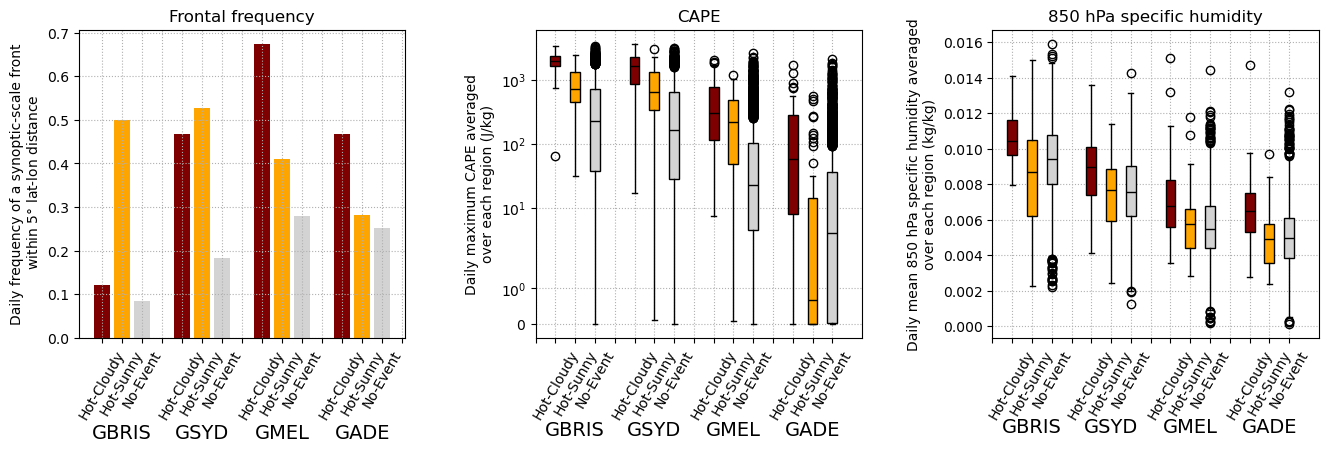

In [9]:
#Plot CAPE

plt.figure(figsize=[16,4])

plt.subplot(1,3,2)
plot = []
labels = [""]
colors = []
for i in [0,1,2,3]:
    print(i)
    plot.append(cape_regional_cases[i])
    plot.append(cape_regional_nulls[i])
    plot.append(cape_regional_non[i])
    plot.append(np.nan)

    labels.append("Hot-Cloudy")
    labels.append("Hot-Sunny")
    labels.append("No-Event")
    labels.append("")

    colors.append("#7f0000")
    colors.append("#FFA500")
    colors.append("lightgrey")
    colors.append("lightgrey")
    
bplot=plt.boxplot(plot,patch_artist=True);

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
for line in bplot['medians']:
    line.set_color("k")

plt.yscale("symlog")
plt.xticks(np.arange(len(plot)), labels[0:-1], rotation=60);
plt.ylabel("Daily maximum CAPE averaged\nover each region (J/kg)")

plt.text(2,-8.5,"GBRIS",transform=plt.gca().transData,ha="center",size=14)
plt.text(6,-8.5,"GSYD",transform=plt.gca().transData,ha="center",size=14)
plt.text(10,-8.5,"GMEL",transform=plt.gca().transData,ha="center",size=14)
plt.text(14,-8.5,"GADE",transform=plt.gca().transData,ha="center",size=14)

plt.gca().grid(ls=":")

plt.title("CAPE")


#Plot huss

plt.subplot(1,3,3)

plot = []
labels = [""]
colors = []
for i in [0,1,2,3]:
    plot.append(huss_regional_cases[i])
    plot.append(huss_regional_nulls[i])
    plot.append(huss_regional_non[i])
    plot.append(np.nan)

    labels.append("Hot-Cloudy")
    labels.append("Hot-Sunny")
    labels.append("No-Event")
    labels.append("")

    colors.append("#7f0000")
    colors.append("#FFA500")
    colors.append("lightgrey")
    colors.append("lightgrey")
    
bplot=plt.boxplot(plot,patch_artist=True);

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
for line in bplot['medians']:
    line.set_color("k")

plt.xticks(np.arange(len(plot)), labels[0:-1], rotation=60);
plt.ylabel("Daily mean 850 hPa specific humidity averaged\nover each region (kg/kg)")

plt.text(2,-0.006,"GBRIS",transform=plt.gca().transData,ha="center",size=14)
plt.text(6,-0.006,"GSYD",transform=plt.gca().transData,ha="center",size=14)
plt.text(10,-0.006,"GMEL",transform=plt.gca().transData,ha="center",size=14)
plt.text(14,-0.006,"GADE",transform=plt.gca().transData,ha="center",size=14)

plt.gca().grid(ls=":")
plt.title("850 hPa specific humidity")


#Plot front frequency
plt.subplot(1,3,1)

#["GADE","GBRI","GMEL","GSYD"]

plot = []
labels = []
colors = []
for i in [0,1,2,3]:
    plot.append(front_regional_cases[i])
    plot.append(front_regional_nulls[i])
    plot.append(front_regional_non[i])
    plot.append(np.nan)

    labels.append("Hot-Cloudy")
    labels.append("Hot-Sunny")
    labels.append("No-Event")
    labels.append("")

    colors.append("#7f0000")
    colors.append("#FFA500")
    colors.append("lightgrey")
    colors.append("lightgrey")
    
plt.bar(np.arange(len(plot)),plot,color=colors);
plt.xticks(np.arange(len(plot)), labels, rotation=60);

plt.text(1,-0.23,"GBRIS",transform=plt.gca().transData,ha="center",size=14)
plt.text(5,-0.23,"GSYD",transform=plt.gca().transData,ha="center",size=14)
plt.text(9,-0.23,"GMEL",transform=plt.gca().transData,ha="center",size=14)
plt.text(13,-0.23,"GADE",transform=plt.gca().transData,ha="center",size=14)

plt.gca().grid(ls=":")

plt.ylabel("Daily frequency of a synoptic-scale front\n within 5$\degree$ lat-lon distance")
plt.title("Frontal frequency")

plt.subplots_adjust(wspace=0.4)

plt.savefig("/g/data/ng72/ab4502/hot-cloudy/figs/fronts_cape_q.jpeg",dpi=400,bbox_inches="tight")

In [10]:
mean_f = f_daily.mean("date").persist()


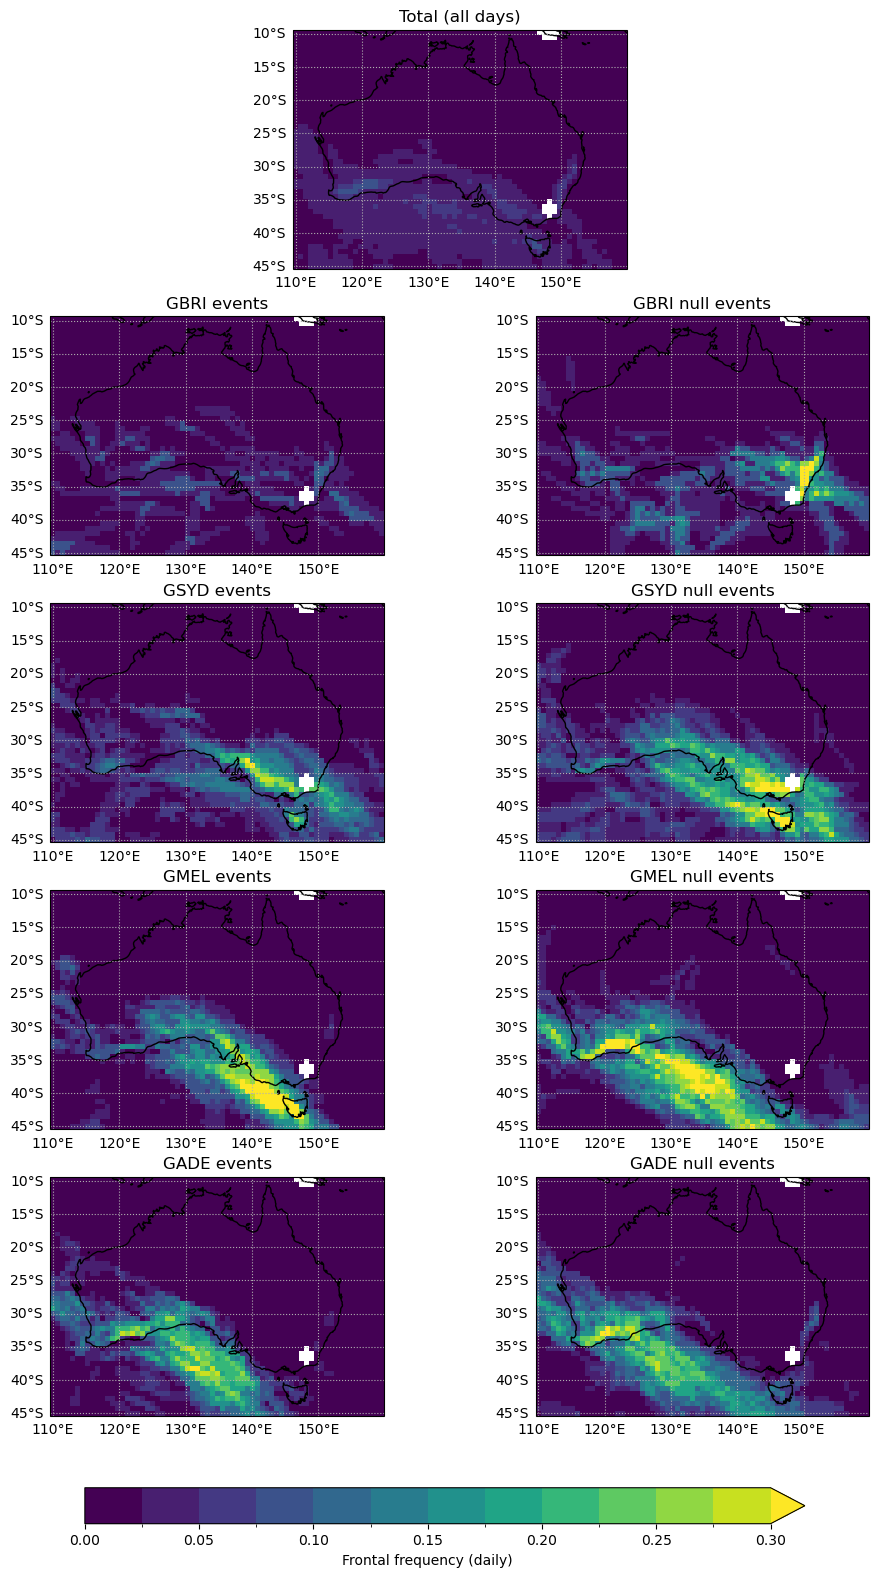

In [28]:
def plot(ax,front):

    front_levs=np.arange(0,0.325,0.025)
    
    xr.plot.pcolormesh(front,levels=front_levs,extend="max",add_colorbar=False)
    ax.coastlines()
    ax.gridlines(ls=":",draw_labels=["left","bottom"])

cnt=1

plt.figure(figsize=[12,18])
for region,i in zip(["GBRI","GSYD","GMEL","GADE"],[0,1,2,3]):

    ax=plt.subplot2grid((5,4),(cnt,0),colspan=2,projection=ccrs.PlateCarree())
    plot(ax,xr.where(front_f.barra_r_missing.isel(time=0),np.nan,front_freq_ls_cases[i]))
    plt.title(region + " events")
        
    ax=plt.subplot2grid((5,4),(cnt,2),colspan=2,projection=ccrs.PlateCarree())
    plot(ax,xr.where(front_f.barra_r_missing.isel(time=0),np.nan,front_freq_ls_nulls[i]))
    plt.title(region + " null events")

    cnt=cnt+1


ax=plt.subplot2grid((5,4),(0,1),colspan=2,projection=ccrs.PlateCarree())
c=xr.where(front_f.barra_r_missing.isel(time=0),np.nan,mean_f).plot(levels=np.arange(0,0.325,0.025),extend="max",add_colorbar=False)
ax.coastlines()    
plt.title("Total (all days)")
ax.gridlines(ls=":",draw_labels=["left","bottom"])
cb=plt.colorbar(c,plt.axes([0.2,0.05,0.6,0.02]),orientation="horizontal")
cb.set_label("Frontal frequency (daily)")

In [ ]:
mean_cape = cape_all_daily.mean("date")

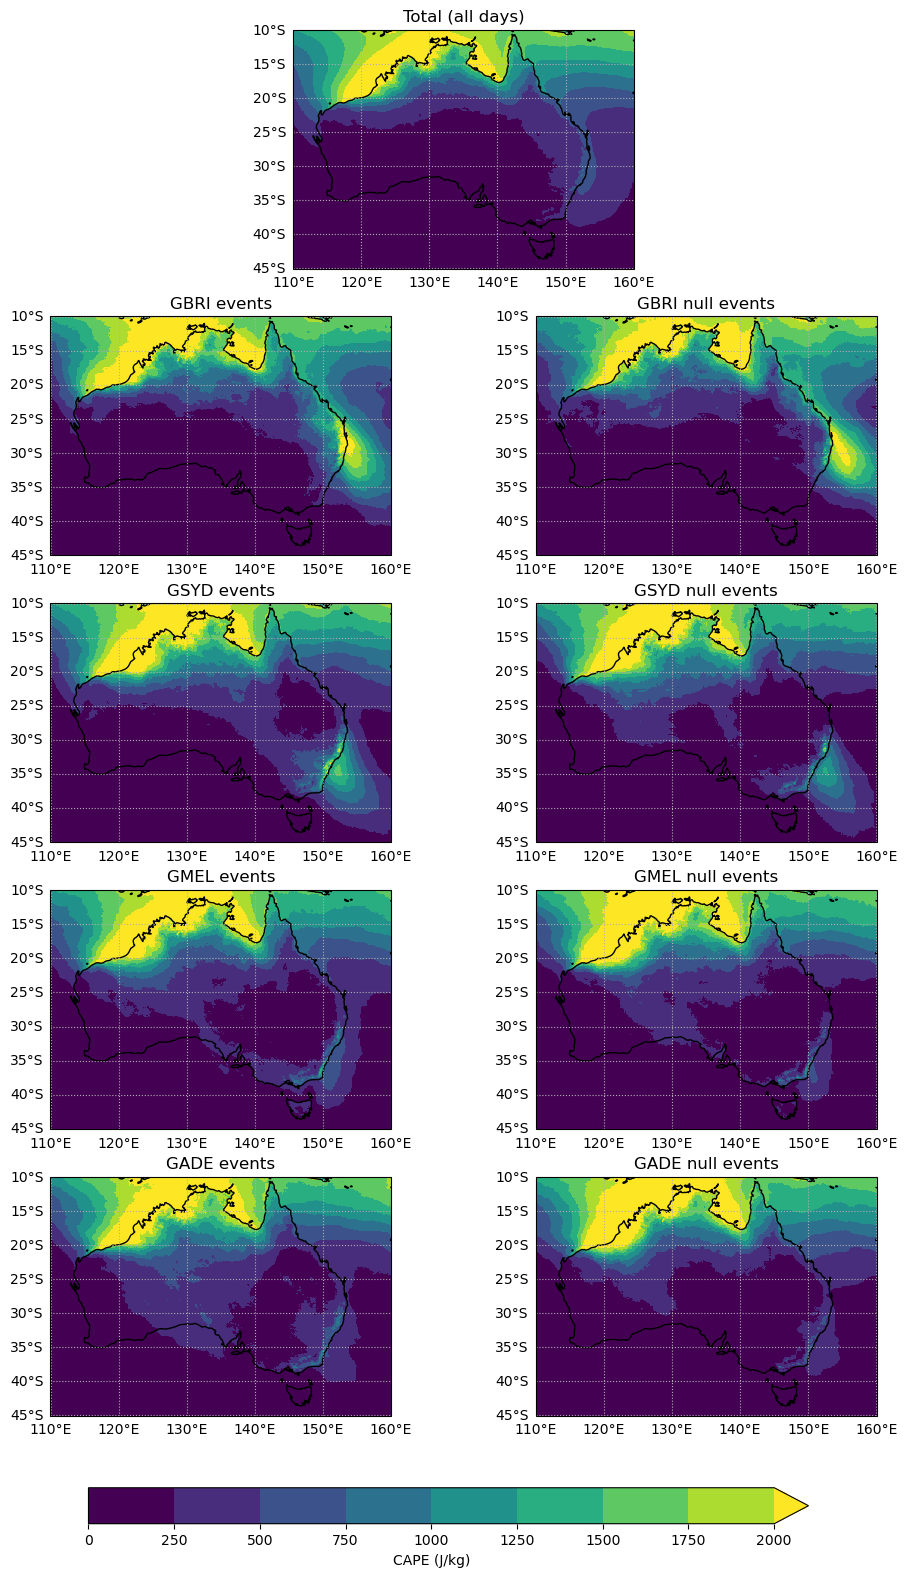

In [34]:
def plot(ax,cape):

    cape_levs=np.arange(0,2250,250)
    
    xr.plot.pcolormesh(cape,levels=cape_levs,extend="max",add_colorbar=False)
    ax.coastlines()
    ax.gridlines(ls=":",draw_labels=["left","bottom"])

cnt=1

plt.figure(figsize=[12,18])
for region,i in zip(["GBRI","GSYD","GMEL","GADE"],[0,1,2,3]):


    ax=plt.subplot2grid((5,4),(cnt,0),colspan=2,projection=ccrs.PlateCarree())
    plot(ax,cape_mean_cases[i])
    plt.title(region + " events")
        
    ax=plt.subplot2grid((5,4),(cnt,2),colspan=2,projection=ccrs.PlateCarree())
    plot(ax,cape_mean_nulls[i])
    plt.title(region + " null events")

    cnt=cnt+1


ax=plt.subplot2grid((5,4),(0,1),colspan=2,projection=ccrs.PlateCarree())
c=mean_cape.plot(levels=np.arange(0,2250,250),extend="max",add_colorbar=False)
ax.coastlines()    
plt.title("Total (all days)")
ax.gridlines(ls=":",draw_labels=["left","bottom"])
cb=plt.colorbar(c,plt.axes([0.2,0.05,0.6,0.02]),orientation="horizontal")
cb.set_label("CAPE (J/kg)")